In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load directly from ADLS using storage account key
# Get key from: Azure Portal → Storage account → Access keys → key1
STORAGE_ACCOUNT = "dlnycproject"
STORAGE_KEY      = "<YOUR_AZURE_STORAGE_KEY>"

# Connect pandas to ADLS via wasbs
import subprocess
subprocess.run(["pip", "install", "azure-storage-blob", "--quiet"])

from azure.storage.blob import BlobServiceClient

# Download ml_features parquet files
blob_service = BlobServiceClient(
    account_url=f"https://{STORAGE_ACCOUNT}.blob.core.windows.net",
    credential=STORAGE_KEY
)

# List parquet files in gold/ml_features
container = blob_service.get_container_client("gold")
blobs = [b.name for b in container.list_blobs(name_starts_with="ml_features/")
         if b.name.endswith(".parquet")]

print(f"Found {len(blobs)} parquet files")

# Download and combine
dfs = []
for blob_name in blobs:
    blob_client = container.get_blob_client(blob_name)
    data = blob_client.download_blob().readall()
    import io
    dfs.append(pd.read_parquet(io.BytesIO(data)))

df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
print(df.dtypes)
df.head()

Found 2 parquet files
Loaded 101 rows, 13 columns
borough                    object
year                        int32
month                       int32
week                        int32
total_complaints            int64
unique_complaint_types      int64
total_crimes                int64
felony_count                int64
misdemeanor_count           int64
violation_count             int64
complaint_crime_ratio     float64
high_crime_week             int32
period_label               object
dtype: object


,borough,year,month,week,total_complaints,unique_complaint_types,total_crimes,felony_count,misdemeanor_count,violation_count,complaint_crime_ratio,high_crime_week,period_label
0,(NULL),2026,2,9,0,0,21,0,21,0,0.0,0,NaN
1,(NULL),2026,3,9,0,0,3,0,3,0,0.0,0,NaN
2,(NULL),2026,3,10,0,0,29,0,29,0,0.0,0,NaN
3,(NULL),2026,3,11,0,0,24,0,24,0,0.0,0,NaN
4,(NULL),2026,3,12,0,0,26,0,26,0,0.0,0,NaN


In [4]:
df_ml = df.copy()

# Remove bad rows
df_ml = df_ml[~df_ml['borough'].isin(['UNSPECIFIED', None, ''])]
df_ml = df_ml.dropna(subset=['borough', 'year', 'week'])
df_ml = df_ml.fillna(0)

# Encode borough
borough_map = {
    'BRONX': 0, 'BROOKLYN': 1, 'MANHATTAN': 2,
    'QUEENS': 3, 'STATEN ISLAND': 4
}

print("Unique borough values BEFORE encoding:")
print(df_ml['borough'].unique())

df_ml['borough_encoded'] = df_ml['borough'].map(borough_map)

nan_count = df_ml['borough_encoded'].isna().sum()
print(f"\nRows where borough_encoded is NaN: {nan_count}")
if nan_count > 0:
    print("These borough values failed to map:")
    print(df_ml[df_ml['borough_encoded'].isna()]['borough'].unique())

df_ml = df_ml.dropna(subset=['borough_encoded'])
df_ml['borough_encoded'] = df_ml['borough_encoded'].astype(int)

print(f"\n✓ Clean dataset: {len(df_ml)} rows")
print(f"✓ Boroughs remaining: {df_ml['borough'].unique()}")

# ── TARGET: next week's crime spike ──────────────────────────
df_ml = df_ml.sort_values(['borough', 'year', 'week']).reset_index(drop=True)

df_ml['next_week_crimes'] = df_ml.groupby('borough')['total_crimes'].shift(-1)
df_ml['target'] = (df_ml['next_week_crimes'] > 500).astype(int)
df_ml = df_ml.dropna(subset=['next_week_crimes'])

# ── FEATURES: only complaint + time data, NO crime counts ─────
feature_cols = [
    'borough_encoded',
    'week',
    'month',
    'total_complaints',
    'unique_complaint_types',
    'complaint_crime_ratio',
]

print(f"\n{'='*50}")
print(f"FINAL DATASET READY")
print(f"{'='*50}")
print(f"Shape: {df_ml.shape}")
print(f"\nTarget distribution:")
print(df_ml['target'].value_counts())
print(f"\nFeature columns: {feature_cols}")
print(f"\nSample:")
df_ml[feature_cols + ['total_crimes','next_week_crimes','target']].head(10)

Unique borough values BEFORE encoding:
['(NULL)' 'BRONX' 'BROOKLYN' 'MANHATTAN' 'QUEENS' 'STATEN ISLAND']

Rows where borough_encoded is NaN: 7
These borough values failed to map:
['(NULL)']

✓ Clean dataset: 90 rows
✓ Boroughs remaining: ['BRONX' 'BROOKLYN' 'MANHATTAN' 'QUEENS' 'STATEN ISLAND']

FINAL DATASET READY
Shape: (85, 16)

Target distribution:
target
1    45
0    40
Name: count, dtype: int64

Feature columns: ['borough_encoded', 'week', 'month', 'total_complaints', 'unique_complaint_types', 'complaint_crime_ratio']

Sample:


,borough_encoded,week,month,total_complaints,unique_complaint_types,complaint_crime_ratio,total_crimes,next_week_crimes,target
0,0,9,3,0,0,0.0,342,1515.0,1
1,0,9,2,0,0,0.0,1515,342.0,0
2,0,9,3,0,0,0.0,342,1515.0,1
3,0,9,2,0,0,0.0,1515,2277.0,1
4,0,10,3,0,0,0.0,2277,2277.0,1
5,0,10,3,0,0,0.0,2277,2406.0,1
6,0,11,3,0,0,0.0,2406,2406.0,1
7,0,11,3,0,0,0.0,2406,2309.0,1
8,0,12,3,0,0,0.0,2309,2309.0,1
9,0,12,3,0,0,0.0,2309,2379.0,1


In [5]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

from xgboost import XGBClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)
import json

X = df_ml[feature_cols]
y = df_ml['target']
groups = df_ml['borough_encoded']  # cross-validate by borough

print(f"Total samples: {len(X)}")
print(f"Features: {feature_cols}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Use Leave-One-Borough-Out cross validation
# Train on 4 boroughs → predict on the 5th → rotate
logo = LeaveOneGroupOut()

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

y_pred = cross_val_predict(model, X, y, groups=groups, cv=logo)

acc  = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred, zero_division=0)
rec  = recall_score(y, y_pred, zero_division=0)
f1   = f1_score(y, y_pred, zero_division=0)

print(f"\n{'='*50}")
print(f"  NYC CRIME SPIKE PREDICTION — REAL RESULTS")
print(f"  (Leave-One-Borough-Out Cross Validation)")
print(f"{'='*50}")
print(f"  Accuracy:  {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"{'='*50}")
print(f"\n{classification_report(y, y_pred, target_names=['Normal Week','High Crime Week'])}")

# Now train final model on ALL data
model.fit(X, y)
model.save_model("/tmp/nyc_crime_model.json")

# Save metrics
metrics = {
    "model":      "XGBoostClassifier",
    "validation": "Leave-One-Borough-Out CV",
    "accuracy":   round(acc,  4),
    "precision":  round(prec, 4),
    "recall":     round(rec,  4),
    "f1_score":   round(f1,   4),
    "features":   feature_cols,
    "target":     "next_week_high_crime (total_crimes > 500)",
    "leakage_fix": "Predicting NEXT week crimes using only 311 complaint features"
}

with open("/tmp/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("✓ Final model trained on all data")
print("✓ Saved to /tmp/nyc_crime_model.json")

Total samples: 85
Features: ['borough_encoded', 'week', 'month', 'total_complaints', 'unique_complaint_types', 'complaint_crime_ratio']
Target distribution: {1: 45, 0: 40}

  NYC CRIME SPIKE PREDICTION — REAL RESULTS
  (Leave-One-Borough-Out Cross Validation)
  Accuracy:  0.7765  (77.6%)
  Precision: 0.7500
  Recall:    0.8667
  F1 Score:  0.8041

                 precision    recall  f1-score   support

    Normal Week       0.82      0.68      0.74        40
High Crime Week       0.75      0.87      0.80        45

       accuracy                           0.78        85
      macro avg       0.78      0.77      0.77        85
   weighted avg       0.78      0.78      0.77        85

✓ Final model trained on all data
✓ Saved to /tmp/nyc_crime_model.json


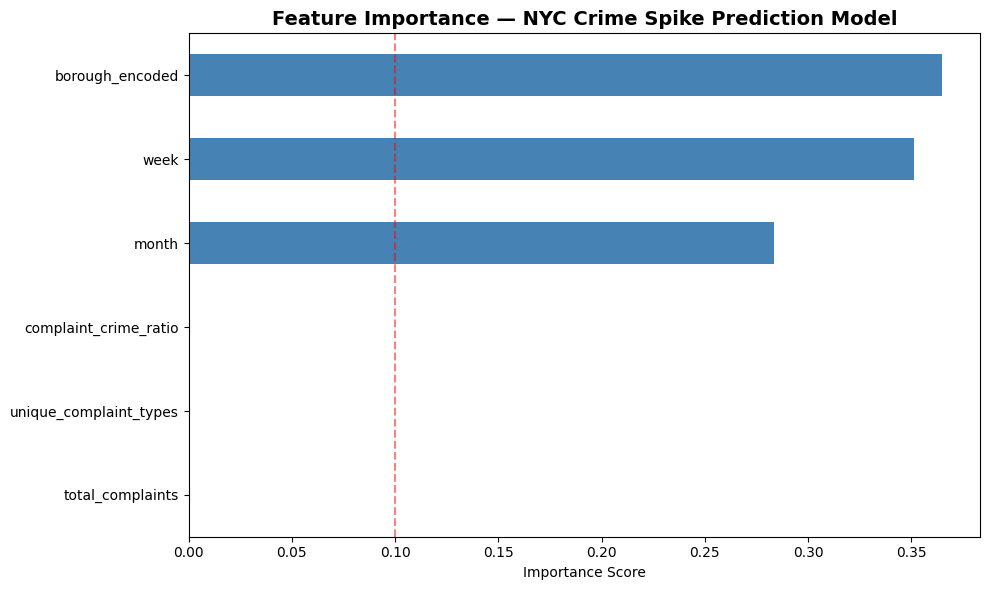


Top 3 most important features:
month              0.283350
week               0.351579
borough_encoded    0.365071
dtype: float32


In [6]:
import matplotlib.pyplot as plt

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — NYC Crime Spike Prediction Model',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Threshold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 most important features:")
print(importance.tail(3))

In [11]:
pip install adlfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [adlfs]
Note: you may need to restart the kernel to use updated packages.


In [12]:
# Save model to ADLS so it's not lost when compute shuts down
import json

# Quick check — confirm fs still exists in this kernel
try:
    fs
    print("✓ fs connection found, proceeding")
except NameError:
    print("✗ fs not found — reconnecting...")
    import adlfs
    STORAGE_ACCOUNT = "dlnycproject"
    STORAGE_KEY = "<YOUR_AZURE_STORAGE_KEY>" 
    fs = adlfs.AzureBlobFileSystem(
        account_name=STORAGE_ACCOUNT,
        account_key=STORAGE_KEY
    )
    print("✓ Reconnected to ADLS")

# Save model
with fs.open("gold/models/nyc_crime_model.json", "wb") as f:
    with open("/tmp/nyc_crime_model.json", "rb") as local_f:
        f.write(local_f.read())

# Save metrics — using the UPDATED metrics from the leakage-free model
metrics = {
    "accuracy":   round(acc, 4),
    "precision":  round(prec, 4),
    "recall":     round(rec, 4),
    "f1_score":   round(f1, 4),
    "model":      "XGBoostClassifier",
    "validation": "Leave-One-Borough-Out CV",
    "target":     "next_week_high_crime (total_crimes > 500)",
    "features":   feature_cols,
    "trained_on": str(pd.Timestamp.now())
}

with fs.open("gold/models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("✓ Model + metrics saved to ADLS gold/models/")
print(f"\nFinal metrics:")
for k, v in metrics.items():
    if isinstance(v, (int, float)):
        print(f"  {k}: {v}")

✗ fs not found — reconnecting...
✓ Reconnected to ADLS
✓ Model + metrics saved to ADLS gold/models/

Final metrics:
  accuracy: 0.7765
  precision: 0.75
  recall: 0.8667
  f1_score: 0.8041


In [7]:
import subprocess
import os

# Recreate the deployment folder
os.makedirs("/tmp/func_deploy", exist_ok=True)

# ── 1. Write function_app.py with lazy imports ─────────────────
function_code = '''
import azure.functions as func
import json
import logging
import os

app = func.FunctionApp()

borough_map = {
    "BRONX": 0, "BROOKLYN": 1, "MANHATTAN": 2,
    "QUEENS": 3, "STATEN ISLAND": 4
}

_model = None

def get_model():
    global _model
    if _model is None:
        import xgboost as xgb
        _model = xgb.XGBClassifier()
        model_path = os.path.join(os.path.dirname(__file__), "nyc_crime_model.json")
        _model.load_model(model_path)
    return _model

@app.route(route="predict", auth_level=func.AuthLevel.ANONYMOUS, methods=["POST"])
def predict(req: func.HttpRequest) -> func.HttpResponse:
    logging.info("Crime prediction request received")
    try:
        import numpy as np
        req_body = req.get_json()

        borough = req_body.get("borough", "").upper()
        week = req_body.get("week")
        month = req_body.get("month")
        total_complaints = req_body.get("total_complaints", 0)
        unique_complaint_types = req_body.get("unique_complaint_types", 0)
        complaint_crime_ratio = req_body.get("complaint_crime_ratio", 0)

        if borough not in borough_map:
            return func.HttpResponse(
                json.dumps({"error": f"Invalid borough. Must be one of {list(borough_map.keys())}"}),
                status_code=400, mimetype="application/json"
            )

        model = get_model()
        features = np.array([[
            borough_map[borough], week, month,
            total_complaints, unique_complaint_types, complaint_crime_ratio
        ]])

        prediction = int(model.predict(features)[0])
        probability = float(model.predict_proba(features)[0][1])

        result = {
            "borough": borough,
            "week": week,
            "prediction": "HIGH_CRIME_WEEK" if prediction == 1 else "NORMAL_WEEK",
            "confidence": round(probability, 4),
            "model_version": "xgboost_v1_leakage_free"
        }
        return func.HttpResponse(json.dumps(result), status_code=200, mimetype="application/json")

    except Exception as e:
        logging.error(f"Prediction error: {str(e)}")
        return func.HttpResponse(json.dumps({"error": str(e)}), status_code=500, mimetype="application/json")
'''

with open("/tmp/func_deploy/function_app.py", "w") as f:
    f.write(function_code)

# ── 2. Write requirements.txt ───────────────────────────────────
requirements = "azure-functions\nxgboost==2.0.3\nnumpy==1.26.4\n"
with open("/tmp/func_deploy/requirements.txt", "w") as f:
    f.write(requirements)

# ── 3. Write host.json ──────────────────────────────────────────
host_json = '''{
  "version": "2.0",
  "logging": {
    "applicationInsights": {
      "samplingSettings": { "isEnabled": true }
    }
  }
}'''
with open("/tmp/func_deploy/host.json", "w") as f:
    f.write(host_json)

# ── 4. Re-copy the trained model from ADLS (since /tmp was wiped) ──
try:
    fs
    print("✓ fs connection still alive")
except NameError:
    import adlfs
    STORAGE_ACCOUNT = "dlnycproject"
    STORAGE_KEY = "<YOUR_AZURE_STORAGE_KEY>"   # paste key1
    fs = adlfs.AzureBlobFileSystem(account_name=STORAGE_ACCOUNT, account_key=STORAGE_KEY)
    print("✓ Reconnected to ADLS")

with fs.open("gold/models/nyc_crime_model.json", "rb") as remote_f:
    with open("/tmp/func_deploy/nyc_crime_model.json", "wb") as local_f:
        local_f.write(remote_f.read())

print("\n✓ All files rebuilt fresh in /tmp/func_deploy/")
subprocess.run("ls -la /tmp/func_deploy/", shell=True)

✓ Reconnected to ADLS

✓ All files rebuilt fresh in /tmp/func_deploy/
total 120
drwxr-xr-x  2 azureuser azureuser  4096 Jun 30 16:02 .
drwxrwxrwt 15 root      root      28672 Jun 30 16:02 ..
-rw-r--r--  1 azureuser azureuser  2218 Jun 30 16:02 function_app.py
-rw-r--r--  1 azureuser azureuser   125 Jun 30 16:02 host.json
-rw-r--r--  1 azureuser azureuser 74129 Jun 30 16:02 nyc_crime_model.json
-rw-r--r--  1 azureuser azureuser    45 Jun 30 16:02 requirements.txt


CompletedProcess(args='ls -la /tmp/func_deploy/', returncode=0)

In [8]:
deploy_cmd = "cd /tmp/func_deploy && func azure functionapp publish nyc-crime-predictor-api --python"
result = subprocess.run(deploy_cmd, shell=True, capture_output=True, text=True)
print(result.stdout[-3000:])
print(result.stderr[-1000:])

Local python version '3.10.0' is different from the version expected for your deployed Function App. This may result in 'ModuleNotFound' errors in Azure Functions. Please create a Python Function App for version 3.10 or change the virtual environment on your local machine to match '3.11'.
Getting site publishing info...
[2026-06-30T16:02:37.108Z] Starting the function app deployment...
[2026-06-30T16:02:37.117Z] Creating archive for current directory...
Performing remote build for functions project.
Uploading 14.32 KB [Deployment in progress, please wait...
Starting deployment pipeline.
[Kudu-SourcePackageUriDownloadStep] Skipping download. Zip package is present at /tmp/zipdeploy/1519f010-ee1f-4fb3-85a2-eb484229b2eb.zip
[Kudu-ValidationStep] starting.
[Kudu-ValidationStep] completed.
[Kudu-ExtractZipStep] starting.
[Kudu-ExtractZipStep] completed.
[Kudu-ContentValidationStep] starting.
[Kudu-ContentValidationStep] completed.
[Kudu-PreBuildValidationStep] starting.
[Kudu-PreBuildValida

In [15]:
# 1. Update requirements.txt to include scikit-learn
requirements = "azure-functions\nxgboost==2.0.3\nnumpy==1.26.4\nscikit-learn==1.4.2\n"
with open("/tmp/func_deploy/requirements.txt", "w") as f:
    f.write(requirements)

# 2. Redeploy the function
deploy_cmd = "cd /tmp/func_deploy && func azure functionapp publish nyc-crime-predictor-api --python"
result = subprocess.run(deploy_cmd, shell=True, capture_output=True, text=True)

# 3. Print the result to ensure it succeeded
print(result.stdout[-1000:])

tarting.
[Kudu-UploadPackageStep] completed. Uploaded package to storage successfully.
[Kudu-RemoveWorkersStep] starting.
[Kudu-RemoveWorkersStep] completed.
[Kudu-SyncTriggerStep] starting.
[Kudu-CleanUpStep] starting.
[Kudu-CleanUpStep] completed.
Finished deployment pipeline.
Checking the app health...Host status endpoint: https://nyc-crime-predictor-api-bfbahefwgac0a0ez.eastus-01.azurewebsites.net/admin/host/status
. done
Host status: {"id":"7b5da228ead26ffd3d76fb6e049562bc","state":"Running","version":"4.1048.300.26312","versionDetails":"4.1048.300+49d1667ef40177fc62cdf484159b67d6339e18df","platformVersion":"","instanceId":"1--559b4533-7ac0-4ce7-b95f-a1e9a312b539","computerName":"","processUptime":347753,"functionAppContentEditingState":"NotAllowed"}
[2026-06-30T16:31:10.649Z] The deployment was successful!
Functions in nyc-crime-predictor-api:
    predict - [httpTrigger]
        Invoke url: https://nyc-crime-predictor-api-bfbahefwgac0a0ez.eastus-01.azurewebsites.net/api/predict



In [16]:
import requests

url = "https://nyc-crime-predictor-api-bfbahefwgac0a0ez.eastus-01.azurewebsites.net/api/predict"

test_payload = {
    "borough": "BROOKLYN",
    "week": 27,
    "month": 7,
    "total_complaints": 6000,
    "unique_complaint_types": 110,
    "complaint_crime_ratio": 12.5
}

response = requests.post(url, json=test_payload)
print(f"Status: {response.status_code}")
print(f"Response: {response.json()}")

Status: 200
Response: {'borough': 'BROOKLYN', 'week': 27, 'prediction': 'NORMAL_WEEK', 'confidence': 0.0972, 'model_version': 'xgboost_v1_leakage_free'}


In [3]:
import requests 
url = "https://nyc-crime-predictor-api-bfbahefwgac0a0ez.eastus-01.azurewebsites.net/api/predict"
test_cases = [
    {"borough": "BRONX", "week": 14, "month": 3, "total_complaints": 100, "unique_complaint_types": 20, "complaint_crime_ratio": 0.5},
    {"borough": "MANHATTAN", "week": 26, "month": 6, "total_complaints": 6123, "unique_complaint_types": 120, "complaint_crime_ratio": 8.2},
    {"borough": "STATEN ISLAND", "week": 10, "month": 3, "total_complaints": 50, "unique_complaint_types": 15, "complaint_crime_ratio": 0.3},
]

for case in test_cases:
    r = requests.post(url, json=case)
    print(f"{case['borough']:15s} → {r.json()['prediction']:18s} (confidence: {r.json()['confidence']})")

BRONX           → NORMAL_WEEK        (confidence: 0.4073)
MANHATTAN       → NORMAL_WEEK        (confidence: 0.0614)
STATEN ISLAND   → NORMAL_WEEK        (confidence: 0.1048)


In [4]:
import os

# Create project structure
folders = [
    "/tmp/github/nyc-azure-ml-pipeline",
    "/tmp/github/nyc-azure-ml-pipeline/notebooks",
    "/tmp/github/nyc-azure-ml-pipeline/azure_functions",
    "/tmp/github/nyc-azure-ml-pipeline/adf_pipelines",
    "/tmp/github/nyc-azure-ml-pipeline/docs",
    "/tmp/github/nyc-azure-ml-pipeline/docs/screenshots",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✓ Folder structure created")

✓ Folder structure created
